#  Workshop: Análise de Dados com Pandas para Iniciantes

Olá! Seja bem-vindo(a) ao nosso workshop prático sobre a biblioteca Pandas do Python!

**Objetivo de hoje:** Nosso objetivo é que, ao final destas 2 horas, você entenda o que é o Pandas, como ele funciona e seja capaz de realizar suas primeiras análises, como importar dados, inspecioná-los e filtrá-los para encontrar informações importantes.

**O que vamos cobrir:**
1.  **O que é o Pandas?** - E por que ele é tão poderoso.
2.  **Estruturas de Dados:** Conhecendo os `Series` e `DataFrames`.
3.  **Leitura de Dados:** Como carregar um arquivo (CSV) no Pandas.
4.  **Inspeção Básica:** Nossos primeiros contatos com um conjunto de dados.
5.  **Seleção e Filtros:** Como encontrar exatamente os dados que você precisa.

Vamos começar!

### 1. Baixando e Importando a Biblioteca Pandas

O primeiro passo em qualquer projeto com Pandas é importar a biblioteca. Por convenção, usamos o alias (apelido) `pd` para facilitar a escrita do código.

In [ ]:
!pip install pandas

In [ ]:
# Execute esta célula para importar o pandas
import pandas as pd

print("Pandas importado com sucesso como pd!")

Pandas importado com sucesso como pd!


### 2. As Estruturas de Dados Fundamentais

O Pandas possui duas estruturas de dados principais que precisamos conhecer. Pense nelas como os blocos de construção para qualquer análise.

#### A. Series: A Coluna de uma Tabela

A `Series` é como uma única coluna em uma planilha. É um array unidimensional que pode armazenar qualquer tipo de dado (números, texto, datas, etc.) e possui um **índice** (index) associado a cada valor.

Vamos criar uma `Series` com as vendas de uma semana.

In [ ]:
# Criando uma Series a partir de uma lista
# Os dados são os valores de vendas
dados_vendas = [100, 150, 90, 210, 130]

# Os índices são os dias da semana
indices_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta']

# Criando a Series
vendas_semana = pd.Series(data=dados_vendas, index=indices_dias)

# Vamos visualizar a Series criada
print(vendas_semana)

Segunda    100
Terça      150
Quarta      90
Quinta     210
Sexta      130
dtype: int64


#### B. DataFrame: A Tabela Completa

O `DataFrame` é a estrutura mais importante e utilizada do Pandas. Ele é como uma planilha ou uma tabela de um banco de dados: uma estrutura bidimensional com linhas e colunas, onde cada coluna é uma `Series`.

Vamos criar um `DataFrame` para armazenar informações de produtos. A forma mais comum de criar um é a partir de um **dicionário** do Python, onde as chaves são os nomes das colunas e os valores são as listas de dados de cada coluna.

In [ ]:
# Criando um dicionário com os dados dos produtos
dados_produtos = {
    'Produto': ['Café', 'Açúcar', 'Leite', 'Pão'],
    'Preço (R$)': [15.50, 4.20, 7.80, 2.50],
    'Quantidade em Estoque': [50, 120, 80, 45],
    'Custo de Produção (R$)': [10.20, 2.00, 5.50, 1.10]
}

# Criando o DataFrame a partir do dicionário
df_produtos = pd.DataFrame(dados_produtos)

# Vamos visualizar o DataFrame criado
# No Colab/Jupyter, simplesmente digitar o nome do DataFrame na última linha já o exibe de forma bonita
df_produtos

,Produto,Preço (R$),Quantidade em Estoque,Custo de Produção (R$)
0,Café,15.5,50,10.2
1,Açúcar,4.2,120,2.0
2,Leite,7.8,80,5.5
3,Pão,2.5,45,1.1


### 3. Manipulando o DataFrame e Criando Novas Colunas

Uma das grandes vantagens do Pandas é a facilidade de criar novas informações a partir de dados existentes. É como adicionar novas fórmulas em uma planilha, mas de forma muito mais poderosa e automatizada.

Imagine que quisessemos avaliar o lucro por unidade, por exemplo. Para isso, vamos criar uma coluna totalmente nova chamada `Lucro por Unidade (R$)`. O valor desta coluna será simplesmente a diferença entre o preço de venda e o custo de produção.

Veja como é simples realizar operações matemáticas entre colunas inteiras. O Pandas aplica a operação linha por linha automaticamente.

In [ ]:
# Criando a nova coluna 'Lucro por Unidade (R$)'
df_produtos['Lucro por Unidade (R$)'] = df_produtos['Preço (R$)'] - df_produtos['Custo de Produção (R$)']

print("DataFrame com a nova coluna de Lucro:")
df_produtos

DataFrame com a nova coluna de Lucro:


,Produto,Preço (R$),Quantidade em Estoque,Custo de Produção (R$),Lucro por Unidade (R$)
0,Café,15.5,50,10.2,5.3
1,Açúcar,4.2,120,2.0,2.2
2,Leite,7.8,80,5.5,2.3
3,Pão,2.5,45,1.1,1.4


### 4. Interagindo com os Dados através de Funções

Podemos ir além e criar funções para simular interações com nossos dados, como uma venda.

Vamos criar uma coluna `Unidades Vendidas` para rastrear as vendas e, em seguida, uma função `realizar_venda` que:
1.  Encontra o produto no DataFrame.
2.  Diminui a quantidade em estoque.
3.  Aumenta o número de unidades vendidas.

Isso demonstra como podemos combinar a lógica do Python com a estrutura de dados do Pandas para criar sistemas mais complexos.

In [ ]:
# Primeiro, vamos adicionar a coluna 'Unidades Vendidas', começando com zero.
df_produtos['Unidades Vendidas'] = 0
df_produtos

,Produto,Preço (R$),Quantidade em Estoque,Custo de Produção (R$),Lucro por Unidade (R$),Unidades Vendidas
0,Café,15.5,50,10.2,5.3,0
1,Açúcar,4.2,120,2.0,2.2,0
2,Leite,7.8,80,5.5,2.3,0
3,Pão,2.5,45,1.1,1.4,0


In [ ]:
# Agora, vamos definir a função para realizar uma venda
def realizar_venda(dataframe, produto_vendido, quantidade=1):
    # Encontra o índice (a linha) do produto vendido
    # .loc é usado para selecionar linhas e colunas por rótulo
    # Diminui o estoque daquele produto
    dataframe.loc[dataframe['Produto'] == produto_vendido, 'Quantidade em Estoque'] -= quantidade

    # Aumenta as unidades vendidas daquele produto
    dataframe.loc[dataframe['Produto'] == produto_vendido, 'Unidades Vendidas'] += quantidade

    print(f"Venda de {quantidade} unidade(s) de '{produto_vendido}' registrada!")


# Vamos visualizar o DataFrame antes da venda
print("--- Estado Inicial do Estoque ---")
display(df_produtos)


# Agora, vamos simular algumas vendas!
print("\n--- Realizando Vendas ---")
realizar_venda(df_produtos, 'Café', quantidade=5)
realizar_venda(df_produtos, 'Pão', quantidade=10)
realizar_venda(df_produtos, 'Leite') # Vende 1 unidade por padrão


# E vamos ver o resultado final!
print("\n--- Estado Final do Estoque após as Vendas ---")
df_produtos

--- Estado Inicial do Estoque ---


,Produto,Preço (R$),Quantidade em Estoque,Custo de Produção (R$),Lucro por Unidade (R$),Unidades Vendidas
0,Café,15.5,50,10.2,5.3,0
1,Açúcar,4.2,120,2.0,2.2,0
2,Leite,7.8,80,5.5,2.3,0
3,Pão,2.5,45,1.1,1.4,0



--- Realizando Vendas ---
Venda de 5 unidade(s) de 'Café' registrada!
Venda de 10 unidade(s) de 'Pão' registrada!
Venda de 1 unidade(s) de 'Leite' registrada!

--- Estado Final do Estoque após as Vendas ---


,Produto,Preço (R$),Quantidade em Estoque,Custo de Produção (R$),Lucro por Unidade (R$),Unidades Vendidas
0,Café,15.5,45,10.2,5.3,5
1,Açúcar,4.2,120,2.0,2.2,0
2,Leite,7.8,79,5.5,2.3,1
3,Pão,2.5,35,1.1,1.4,10


Muito bem! Agora que temos o lucro por unidade e o número de unidades vendidas, podemos facilmente calcular o lucro total gerado por cada produto até o momento.

Esta é mais uma operação vetorial (coluna inteira), onde simplesmente multiplicamos os valores de duas colunas existentes para criar uma nova.

In [ ]:
# Calculando o lucro total multiplicando o lucro por unidade pelas unidades vendidas
df_produtos['Lucro Total (R$)'] = df_produtos['Lucro por Unidade (R$)'] * df_produtos['Unidades Vendidas']

# Exibindo o DataFrame final com todos os nossos cálculos!
# Este DataFrame agora nos dá uma visão completa do nosso mini-estoque.
print("--- Visão Final com Lucro Total por Produto ---")
df_produtos

--- Visão Final com Lucro Total por Produto ---


,Produto,Preço (R$),Quantidade em Estoque,Custo de Produção (R$),Lucro por Unidade (R$),Unidades Vendidas,Lucro Total (R$)
0,Café,15.5,45,10.2,5.3,5,26.5
1,Açúcar,4.2,120,2.0,2.2,0,0.0
2,Leite,7.8,79,5.5,2.3,1,2.3
3,Pão,2.5,35,1.1,1.4,10,14.0


**Análise Rápida:**

Com esta tabela final, podemos responder rapidamente a perguntas como:
* Qual produto nos deu mais lucro até agora? (Olhando a coluna `Lucro Total (R$)`)
* Quantas unidades de Pão ainda temos? (Olhando a `Quantidade em Estoque`)

### 5. Integrando Dados de Múltiplas Fontes

Na vida real, os dados raramente vêm em uma única tabela perfeitamente organizada. É comum termos informações espalhadas em diferentes arquivos ou sistemas. Uma das operações mais poderosas do Pandas é a capacidade de combinar (ou "mergir") DataFrames com base em colunas em comum, como se estivéssemos juntando tabelas em um banco de dados.

Vamos usar o `df_produtos` que já criamos e criar um segundo DataFrame para simularmos essa situação. O novo DataFrame terá informações adicionais sobre os produtos, como categoria e fornecedor.

In [ ]:
# Já temos o df_produtos criado nas seções anteriores. Vamos visualizá-lo novamente:
print("DataFrame de Produtos (já existente):")
display(df_produtos)

# Criando o segundo DataFrame: Informações Adicionais de Produtos
dados_info_produtos = {
    'Produto': ['Café', 'Açúcar', 'Leite', 'Pão'],
    'Categoria': ['Bebida', 'Mercearia', 'Laticínio', 'Padaria'],
    'Fornecedor': ['Fornecedor A', 'Fornecedor B', 'Fornecedor C', 'Fornecedor A']
}
df_info_produtos = pd.DataFrame(dados_info_produtos)

print("\nDataFrame com Informações Adicionais de Produtos:")
display(df_info_produtos)

DataFrame de Produtos (já existente):


,Produto,Preço (R$),Quantidade em Estoque,Custo de Produção (R$),Lucro por Unidade (R$),Unidades Vendidas,Lucro Total (R$)
0,Café,15.5,45,10.2,5.3,5,26.5
1,Açúcar,4.2,120,2.0,2.2,0,0.0
2,Leite,7.8,79,5.5,2.3,1,2.3
3,Pão,2.5,35,1.1,1.4,10,14.0



DataFrame com Informações Adicionais de Produtos:


,Produto,Categoria,Fornecedor
0,Café,Bebida,Fornecedor A
1,Açúcar,Mercearia,Fornecedor B
2,Leite,Laticínio,Fornecedor C
3,Pão,Padaria,Fornecedor A


Agora, queremos combinar as informações do `df_produtos` com as informações adicionais do `df_info_produtos` para ter uma visão mais completa de cada produto. Para isso, usaremos a função `pd.merge()`.

Precisamos especificar:
*   Os dois DataFrames a serem mesclados (`df_produtos` e `df_info_produtos`).
*   A coluna em comum que será usada para o casamento dos dados (`on='Produto'`).
*   O tipo de junção (`how='inner'`). O tipo `inner` (junção interna) só inclui as linhas onde a coluna em comum tem valores presentes em AMBOS os DataFrames. Existem outros tipos (`left`, `right`, `outer`) que veremos mais adiante, se necessário.

In [ ]:
# Realizando a junção (merge) dos DataFrames
df_produtos_completo = pd.merge(df_produtos, df_info_produtos, on='Produto', how='inner')

print("DataFrame Combinado (Produtos com Informações Adicionais):")
display(df_produtos_completo)

DataFrame Combinado (Produtos com Informações Adicionais):


,Produto,Preço (R$),Quantidade em Estoque,Custo de Produção (R$),Lucro por Unidade (R$),Unidades Vendidas,Lucro Total (R$),Categoria,Fornecedor
0,Café,15.5,45,10.2,5.3,5,26.5,Bebida,Fornecedor A
1,Açúcar,4.2,120,2.0,2.2,0,0.0,Mercearia,Fornecedor B
2,Leite,7.8,79,5.5,2.3,1,2.3,Laticínio,Fornecedor C
3,Pão,2.5,35,1.1,1.4,10,14.0,Padaria,Fornecedor A


Como você pode ver, o novo DataFrame `df_produtos_completo` agora contém todas as colunas dos dois DataFrames originais, alinhadas corretamente pela coluna `Produto`.

Esta é uma operação fundamental em análise de dados e você a utilizará constantemente para enriquecer seus conjuntos de dados combinando informações de diferentes fontes.

Isso conclui nossa introdução à criação e manipulação de DataFrames "na mão". O próximo passo é aprender a carregar dados de fontes externas, como arquivos CSV, que é a forma como você trabalhará na maioria dos projetos de análise de dados.

---
## Parte 2: Trabalhando com um Conjunto de Dados Real

Até agora, nós criamos nossos próprios dados. Na prática, o mais comum é carregar dados de uma fonte externa. O formato mais popular para armazenar e compartilhar dados tabulares é o **CSV** (Comma-Separated Values, ou Valores Separados por Vírgula).

Vamos carregar um famoso dataset com dados de vendas de videogames desde os anos 80. Ele contém informações como o nome do jogo, plataforma, ano de lançamento, gênero e vendas em diferentes regiões do mundo (em milhões de cópias).

Usaremos a função `pd.read_csv()`, que é a porta de entrada para a análise de dados com Pandas.

In [ ]:
path = 'vgsales.csv'

# Vamos carregar os dados para um novo DataFrame chamado df_games
df_games = pd.read_csv(path)

print("Dataset de Vendas de Videogames carregado com sucesso!")

Dataset de Vendas de Videogames carregado com sucesso!


### 6. Inspeção Inicial do Dataset

O passo **mais importante** após carregar qualquer novo conjunto de dados é fazer uma inspeção inicial. Nunca comece a analisar sem antes entender a estrutura dos seus dados.

Vamos usar os comandos que já conhecemos para fazer esse diagnóstico:

* `.head()`: Para "espiar" as primeiras linhas e entender as colunas.
* `.shape`: Para saber exatamente quantas linhas e colunas temos.
* `.info()`: Para ver um resumo técnico, incluindo os tipos de dados de cada coluna e, crucialmente, a contagem de valores não nulos.

In [ ]:
# 1. Vamos ver as 5 primeiras linhas do nosso novo DataFrame
print("--- Visualizando as primeiras 5 linhas ---")
display(df_games.head())

--- Visualizando as primeiras 5 linhas ---


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
# 2. Vamos verificar o formato (linhas, colunas)
print("\n--- Formato do DataFrame (linhas, colunas) ---")
print(df_games.shape)


--- Formato do DataFrame (linhas, colunas) ---
(16598, 11)


In [ ]:
# 3. Vamos obter o resumo técnico
print("\n--- Informações Técnicas do DataFrame ---")
df_games.info()


--- Informações Técnicas do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


### Análise da Inspeção

O que descobrimos com a célula acima?

1.  **`.head()`**: Vimos as colunas que temos: `Rank`, `Name`, `Platform`, `Year`, `Genre`, `Publisher`, e as colunas de vendas.
2.  **`.shape`**: Descobrimos que o dataset tem **16.598 linhas (jogos)** e **11 colunas (informações)**. É um dataset considerável!
3.  **`.info()`**: Esta é a parte mais rica!
    * Vemos os tipos de cada coluna (`Dtype`). `Year` é `float64` (decimal), o que é um pouco estranho, mas podemos lidar com isso. As vendas também são `float64`.
    * **Importante:** A linha `RangeIndex: 16598 entries` nos diz o total de linhas. Se olharmos a contagem da coluna `Year` (`16327 non-null`), vemos que ela é **menor** que o total. Isso significa que existem **271 jogos sem o ano de lançamento preenchido** (16598 - 16327).
    * O mesmo acontece com a coluna `Publisher`, que tem 58 valores faltando.

Essa investigação inicial é fundamental e já nos dá um roteiro para os próximos passos de limpeza e análise.

### 7. Limpeza Básica de Dados

Como vimos na inspeção, nosso dataset não é perfeito. A coluna `Year` tem valores faltando e está com o tipo de dado incorreto (`float64` em vez de `int`). Antes de analisar, é uma boa prática corrigir esses problemas.

**Passo 1: Lidando com Dados Faltantes**

Temos 271 jogos sem ano de lançamento. Para uma análise simples, a forma mais direta de lidar com isso é remover as linhas que contêm esses dados faltantes. Usaremos o método `.dropna()`. Vamos focar em remover apenas as linhas onde o 'Ano' (`Year`) está faltando.

In [ ]:
# Mostrando o número de linhas ANTES da limpeza
print(f"Número de linhas antes da remoção: {df_games.shape[0]}")

# .dropna() remove linhas (ou colunas) com valores nulos (NaN)
# O parâmetro 'subset' nos permite especificar em qual coluna queremos procurar por valores nulos
df_games_limpo = df_games.dropna(subset=['Year'])

# Mostrando o número de linhas DEPOIS da limpeza
print(f"Número de linhas após a remoção: {df_games_limpo.shape[0]}")

Número de linhas antes da remoção: 16598
Número de linhas após a remoção: 16327


**Passo 2: Corrigindo o Tipo de Dado da Coluna 'Year'**

Agora que removemos as linhas com anos faltando, não há mais o risco de erros ao converter a coluna `Year` para um número inteiro. Usaremos o método `.astype()` para fazer essa conversão.

In [ ]:
# Convertendo a coluna 'Year' de float para int
# É comum precisarmos fazer esse tipo de ajuste nos dados
df_games_limpo['Year'] = df_games_limpo['Year'].astype(int)

# Vamos verificar as informações novamente para confirmar as mudanças
print("--- Informações após a Limpeza e Correção ---")
df_games_limpo.info()

# Note que 'Year' agora é 'int64' e tem 16327 valores, o mesmo número de entradas do DataFrame.

--- Informações após a Limpeza e Correção ---
<class 'pandas.core.frame.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16327 non-null  int64  
 1   Name          16327 non-null  object 
 2   Platform      16327 non-null  object 
 3   Year          16327 non-null  int64  
 4   Genre         16327 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16327 non-null  float64
 7   EU_Sales      16327 non-null  float64
 8   JP_Sales      16327 non-null  float64
 9   Other_Sales   16327 non-null  float64
 10  Global_Sales  16327 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.5+ MB


/tmp/ipython-input-25-2187851792.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_games_limpo['Year'] = df_games_limpo['Year'].astype(int)


### 8. Fazendo Perguntas ao Nosso Dataset

Agora com os dados mais organizados, podemos começar a parte divertida! Vamos fazer perguntas e usar o Pandas para respondê-las.

**Pergunta 1: Quais são os 10 jogos mais vendidos de todos os tempos?**

A coluna `Global_Sales` representa o total de vendas em milhões. Para responder a essa pergunta, podemos simplesmente ordenar nosso DataFrame por essa coluna em ordem decrescente.

In [ ]:
# O método .sort_values() ordena o DataFrame por uma ou mais colunas.
# 'by' especifica a coluna de ordenação.
# 'ascending=False' ordena do maior para o menor.
top_10_vendidos = df_games_limpo.sort_values(by='Global_Sales', ascending=False)

# Usando .head(10) para ver apenas os 10 primeiros da lista ordenada.
print("--- Top 10 Jogos Mais Vendidos Globalmente ---")
top_10_vendidos.head(10)

--- Top 10 Jogos Mais Vendidos Globalmente ---


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


**Pergunta 2: Quais foram os jogos de maior sucesso do console 'Wii'?**

E se quisermos analisar uma plataforma específica? Podemos criar um filtro para selecionar apenas as linhas que correspondem à plataforma 'Wii'.

In [ ]:
# Primeiro, criamos a condição de filtro: queremos linhas onde a coluna 'Platform' seja igual a 'Wii'.
condicao_wii = df_games_limpo['Platform'] == 'Wii'

# Em seguida, usamos essa condição para selecionar as linhas do DataFrame.
df_wii = df_games_limpo[condicao_wii]

# Agora, df_wii é um novo DataFrame contendo APENAS jogos de Wii.
# Vamos ordená-lo por vendas para ver os mais vendidos dessa plataforma.
top_wii_vendidos = df_wii.sort_values(by='Global_Sales', ascending=False)

print("--- Top 10 Jogos Mais Vendidos para Nintendo Wii ---")
top_wii_vendidos.head(10)

--- Top 10 Jogos Mais Vendidos para Nintendo Wii ---


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
7,8,Wii Play,Wii,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
13,14,Wii Fit,Wii,2007,Sports,Nintendo,8.94,8.03,3.60,2.15,22.72
14,15,Wii Fit Plus,Wii,2009,Sports,Nintendo,9.09,8.59,2.53,1.79,22.00
39,40,Super Smash Bros. Brawl,Wii,2008,Fighting,Nintendo,6.75,2.61,2.66,1.02,13.04
48,49,Super Mario Galaxy,Wii,2007,Platform,Nintendo,6.16,3.40,1.20,0.76,11.52
60,61,Just Dance 3,Wii,2011,Misc,Ubisoft,6.05,3.15,0.00,1.07,10.26


### 9. Agregando Dados para Obter Insights Profundos com `groupby`

Filtrar e ordenar é ótimo para analisar entradas individuais. Mas e se quisermos responder a perguntas sobre categorias inteiras? Por exemplo:
* "Qual gênero de jogo vende mais no total?"
* "Qual plataforma tem a maior média de vendas por jogo?"

Para isso, usamos o método `.groupby()`, que funciona de forma parecida com as Tabelas Dinâmicas do Excel. A lógica é **"Dividir-Aplicar-Combinar"**:
1.  **Dividir (Split):** O Pandas divide o DataFrame em grupos menores com base em uma categoria (ex: 'Genre' ou 'Platform').
2.  **Aplicar (Apply):** Ele aplica uma função de agregação a cada grupo (ex: `sum()` para somar, `mean()` para calcular a média, `count()` para contar).
3.  **Combinar (Combine):** Ele combina os resultados de cada grupo em um novo DataFrame.

**Pergunta 3: Qual é o total de vendas globais por gênero de jogo?**

In [ ]:
# 1. Agrupamos o DataFrame por 'Genre'.
# 2. Selecionamos a coluna 'Global_Sales' para o cálculo.
# 3. Aplicamos a função de soma (.sum()) a cada grupo.
vendas_por_genero = df_games_limpo.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

# O resultado é uma nova Series com o gênero como índice e a soma das vendas como valor.
print("--- Total de Vendas (em milhões) por Gênero ---")
vendas_por_genero

--- Total de Vendas (em milhões) por Gênero ---


,Global_Sales
Genre,
Action,1722.88
Sports,1309.24
Shooter,1026.20
Role-Playing,923.84
Platform,829.15
Misc,797.62
Racing,726.77
Fighting,444.05
Simulation,390.16


**Pergunta 4: Análise por Plataforma - Qual a venda média e quantos jogos foram lançados por console?**

O `.groupby()` é ainda mais poderoso quando queremos calcular múltiplas métricas ao mesmo tempo. Usando o método `.agg()`, podemos passar um dicionário de agregações a serem feitas.

Vamos descobrir:
1.  A **média** de vendas (`mean`) para a coluna `Global_Sales`.
2.  A **contagem** de jogos (`count`) para a coluna `Name`.

In [ ]:
# Usando .agg() para aplicar múltiplas funções de agregação de uma só vez
analise_plataforma = df_games_limpo.groupby('Platform').agg(
    Venda_Media_Global=('Global_Sales', 'mean'),
    Numero_de_Jogos=('Name', 'count')
).sort_values(by='Venda_Media_Global', ascending=False)

# Vamos arredondar a venda média para 2 casas decimais para facilitar a leitura
analise_plataforma['Venda_Media_Global'] = analise_plataforma['Venda_Media_Global'].round(2)

print("--- Análise de Venda Média e Quantidade de Jogos por Plataforma ---")
analise_plataforma.head(10)

--- Análise de Venda Média e Quantidade de Jogos por Plataforma ---


,Venda_Media_Global,Numero_de_Jogos
Platform,,
GB,2.62,97
NES,2.56,98
GEN,1.05,27
SNES,0.84,239
PS4,0.83,336
X360,0.79,1235
2600,0.75,116
PS3,0.73,1304
Wii,0.71,1290


### 10. Visualizando Nossos Resultados

Números e tabelas são ótimos, mas um bom gráfico pode revelar padrões e insights de forma muito mais rápida e impactante.

Vamos criar algumas visualizações simples para os resultados que acabamos de encontrar usando a biblioteca `matplotlib`, a parceira mais comum do Pandas para gráficos.

Primeiro, precisamos importar a biblioteca. A convenção é usar o alias `plt`. Também adicionamos uma "palavra mágica" (`%matplotlib inline`) para garantir que os gráficos apareçam diretamente aqui no nosso notebook.

In [ ]:
!pip install matplotlib

In [ ]:
import matplotlib.pyplot as plt

# Comando para exibir gráficos diretamente no notebook
%matplotlib inline

**Gráfico 1: Total de Vendas Globais por Gênero**

Vamos transformar nossa tabela de vendas por gênero em um gráfico de barras. É a maneira perfeita de comparar os totais entre as diferentes categorias.

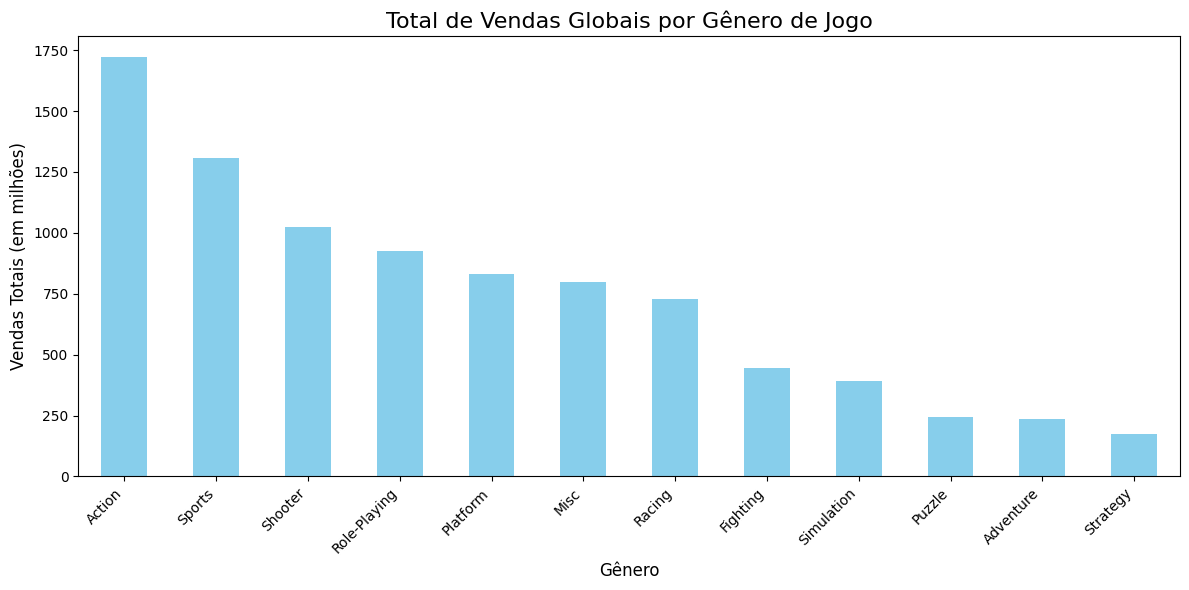

In [ ]:
# O Pandas torna muito fácil plotar diretamente de uma Series ou DataFrame
# Usamos .plot(kind='bar') para um gráfico de barras
# figsize=(12, 6) define o tamanho da figura para melhor visualização

vendas_por_genero.plot(kind='bar', figsize=(12, 6), color='skyblue')

# Adicionando títulos e rótulos para deixar o gráfico mais claro
plt.title('Total de Vendas Globais por Gênero de Jogo', fontsize=16)
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Vendas Totais (em milhões)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotaciona os nomes dos gêneros para não sobrepor

# Ajusta o layout para garantir que nada seja cortado
plt.tight_layout()

# Exibe o gráfico
plt.show()

**Gráfico 2: Média de Vendas por Plataforma (Top 10)**

Agora, vamos visualizar a outra análise que fizemos: a venda média por plataforma. Vamos focar nas 10 plataformas com a maior média para manter o gráfico limpo.

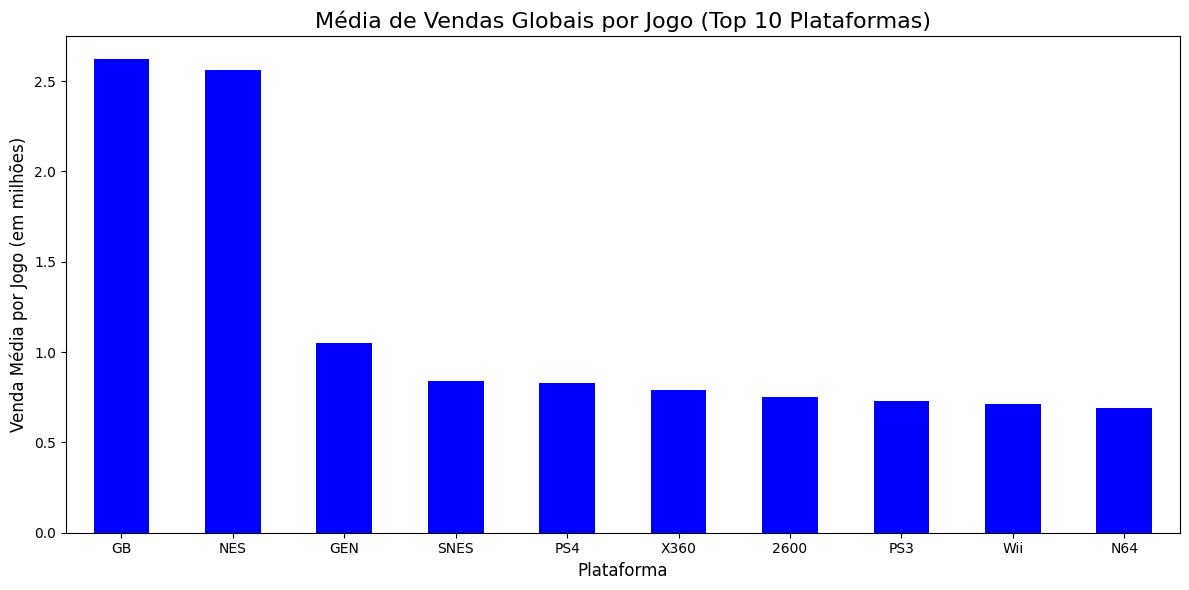

In [ ]:
# Primeiro, pegamos apenas as 10 primeiras plataformas da nossa análise já ordenada
top_10_plataformas_media = analise_plataforma.head(10)

# Criamos o gráfico de barras
top_10_plataformas_media['Venda_Media_Global'].plot(kind='bar', figsize=(12, 6), color='blue')

# Adicionando títulos e rótulos
plt.title('Média de Vendas Globais por Jogo (Top 10 Plataformas)', fontsize=16)
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Venda Média por Jogo (em milhões)', fontsize=12)
plt.xticks(rotation=0) # Mantém os nomes das plataformas na horizontal

plt.tight_layout()
plt.show()

Com estes gráficos, as conclusões ficam evidentes: o gênero "Action" domina em volume total de vendas, enquanto plataformas mais antigas como "Game Boy" se destacam por uma altíssima média de vendas por jogo lançado.

A visualização de dados é uma etapa crucial e poderosa no processo de análise!

---
# 🎉 Parabéns e Muito Obrigado! 🎉

Chegamos ao final do nosso workshop prático de Pandas!

Gostaríamos de parabenizar você por todo o empenho e curiosidade. Em apenas duas horas, você percorreu um caminho completo que é a base para qualquer projeto de análise de dados.

### O que você conquistou hoje:
* **Entendeu os Fundamentos:** Compreendeu o que são as `Series` e os `DataFrames`, os pilares do Pandas.
* **Carregou Dados do Mundo Real:** Usou `pd.read_csv` para importar um dataset diretamente da internet.
* **Atuou como um Detetive de Dados:** Inspecionou os dados com `.head()`, `.shape()` e `.info()` para encontrar problemas e oportunidades.
* **Realizou Limpeza e Transformação:** Corrigiu tipos de dados com `.astype()` e lidou com valores ausentes usando `.dropna()`.
* **Respondeu Perguntas de Negócio:** Extraiu insights valiosos através de filtros, ordenação (`.sort_values()`) e agregações complexas com `.groupby()`.
* **Comunicou seus Insights:** Criou visualizações claras com `.plot()` para apresentar suas descobertas de forma gráfica.

Você agora tem uma base sólida para começar a automatizar suas análises, otimizar seu trabalho com planilhas e dar os primeiros passos em uma carreira na área de dados.

### Próximos Passos na sua Jornada:

A aventura está apenas começando! Se você gostou do que viu e quer continuar aprendendo, recomendamos explorar:

1.  **Junção de Tabelas:** Pesquise por `pd.merge()`, a função do Pandas para combinar diferentes fontes de dados (o equivalente ao PROCV do Excel, mas muito mais poderoso).
2.  **Visualização Avançada:** Conheça a biblioteca **Seaborn**, que é construída sobre o Matplotlib e permite criar gráficos estatísticos sofisticados com poucas linhas de código.
3.  **Pratique, Pratique, Pratique:** A melhor forma de aprender é fazendo! Procure por datasets públicos em sites como o **Kaggle** ou o **dados.gov.br** e tente responder suas próprias perguntas.

---

Agradecemos imensamente a sua participação e esperamos que este workshop tenha sido útil e inspirador.

**O seu certificado de participação será enviado para o email utilizado na inscrição.**

**Boa sorte em suas futuras análises!**